In [1]:
!unzip -q tyre.zip -d /content/tyre_dataset

In [ ]:
! pip install ultralytics


In [4]:
import os
import cv2
import shutil
from ultralytics import YOLO
import yaml
import glob
import random
import matplotlib.pyplot as plt
from IPython.display import Image, display

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
base_dir = '/content/tyre_dataset'
new_base_dir = '/content/car_tyre_dataset'
car_model = YOLO('yolov8n.pt')
splits = ['train', 'valid', 'test']

for split in splits:
    img_dir = os.path.join(base_dir, split, 'images')
    lbl_dir = os.path.join(base_dir, split, 'labels')
    new_img_dir = os.path.join(new_base_dir, split, 'images')
    new_lbl_dir = os.path.join(new_base_dir, split, 'labels')

    os.makedirs(new_img_dir, exist_ok=True)
    os.makedirs(new_lbl_dir, exist_ok=True)

    if not os.path.exists(img_dir):
        continue

    for img_name in os.listdir(img_dir):
        if not img_name.endswith(('.jpg', '.jpeg', '.png')):
            continue

        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, img_name.rsplit('.', 1)[0] + '.txt')
        new_img_path = os.path.join(new_img_dir, img_name)
        new_lbl_path = os.path.join(new_lbl_dir, img_name.rsplit('.', 1)[0] + '.txt')

        shutil.copy(img_path, new_img_path)

        existing_lines = []
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        existing_lines.append(f"1 {parts[1]} {parts[2]} {parts[3]} {parts[4]}\n")

        results = car_model.predict(img_path, classes=[2], verbose=False)
        car_lines = []
        img = cv2.imread(img_path)
        h, w = img.shape[:2]

        for r in results:
            if r.boxes is not None:
                for box in r.boxes:
                    x1, y1, x2, y2 = map(float, box.xyxy[0])
                    cx = ((x1 + x2) / 2) / w
                    cy = ((y1 + y2) / 2) / h
                    bw = (x2 - x1) / w
                    bh = (y2 - y1) / h
                    car_lines.append(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

        with open(new_lbl_path, 'w') as f:
            f.writelines(car_lines)
            f.writelines(existing_lines)

In [6]:
data_config = {
    'path': '/content/car_tyre_dataset',
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 2,
    'names': {0: 'car', 1: 'tyre'}
}

with open('/content/car_tyre_dataset/dataset.yaml', 'w') as f:
    yaml.dump(data_config, f)

model_combined = YOLO("yolov8n.pt")

results = model_combined.train(
    data="/content/car_tyre_dataset/dataset.yaml",
    epochs=15,
    imgsz=640,
    project="car_tyre_project",
    name="combined_model"
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/car_tyre_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=combined_model, nbs=64,

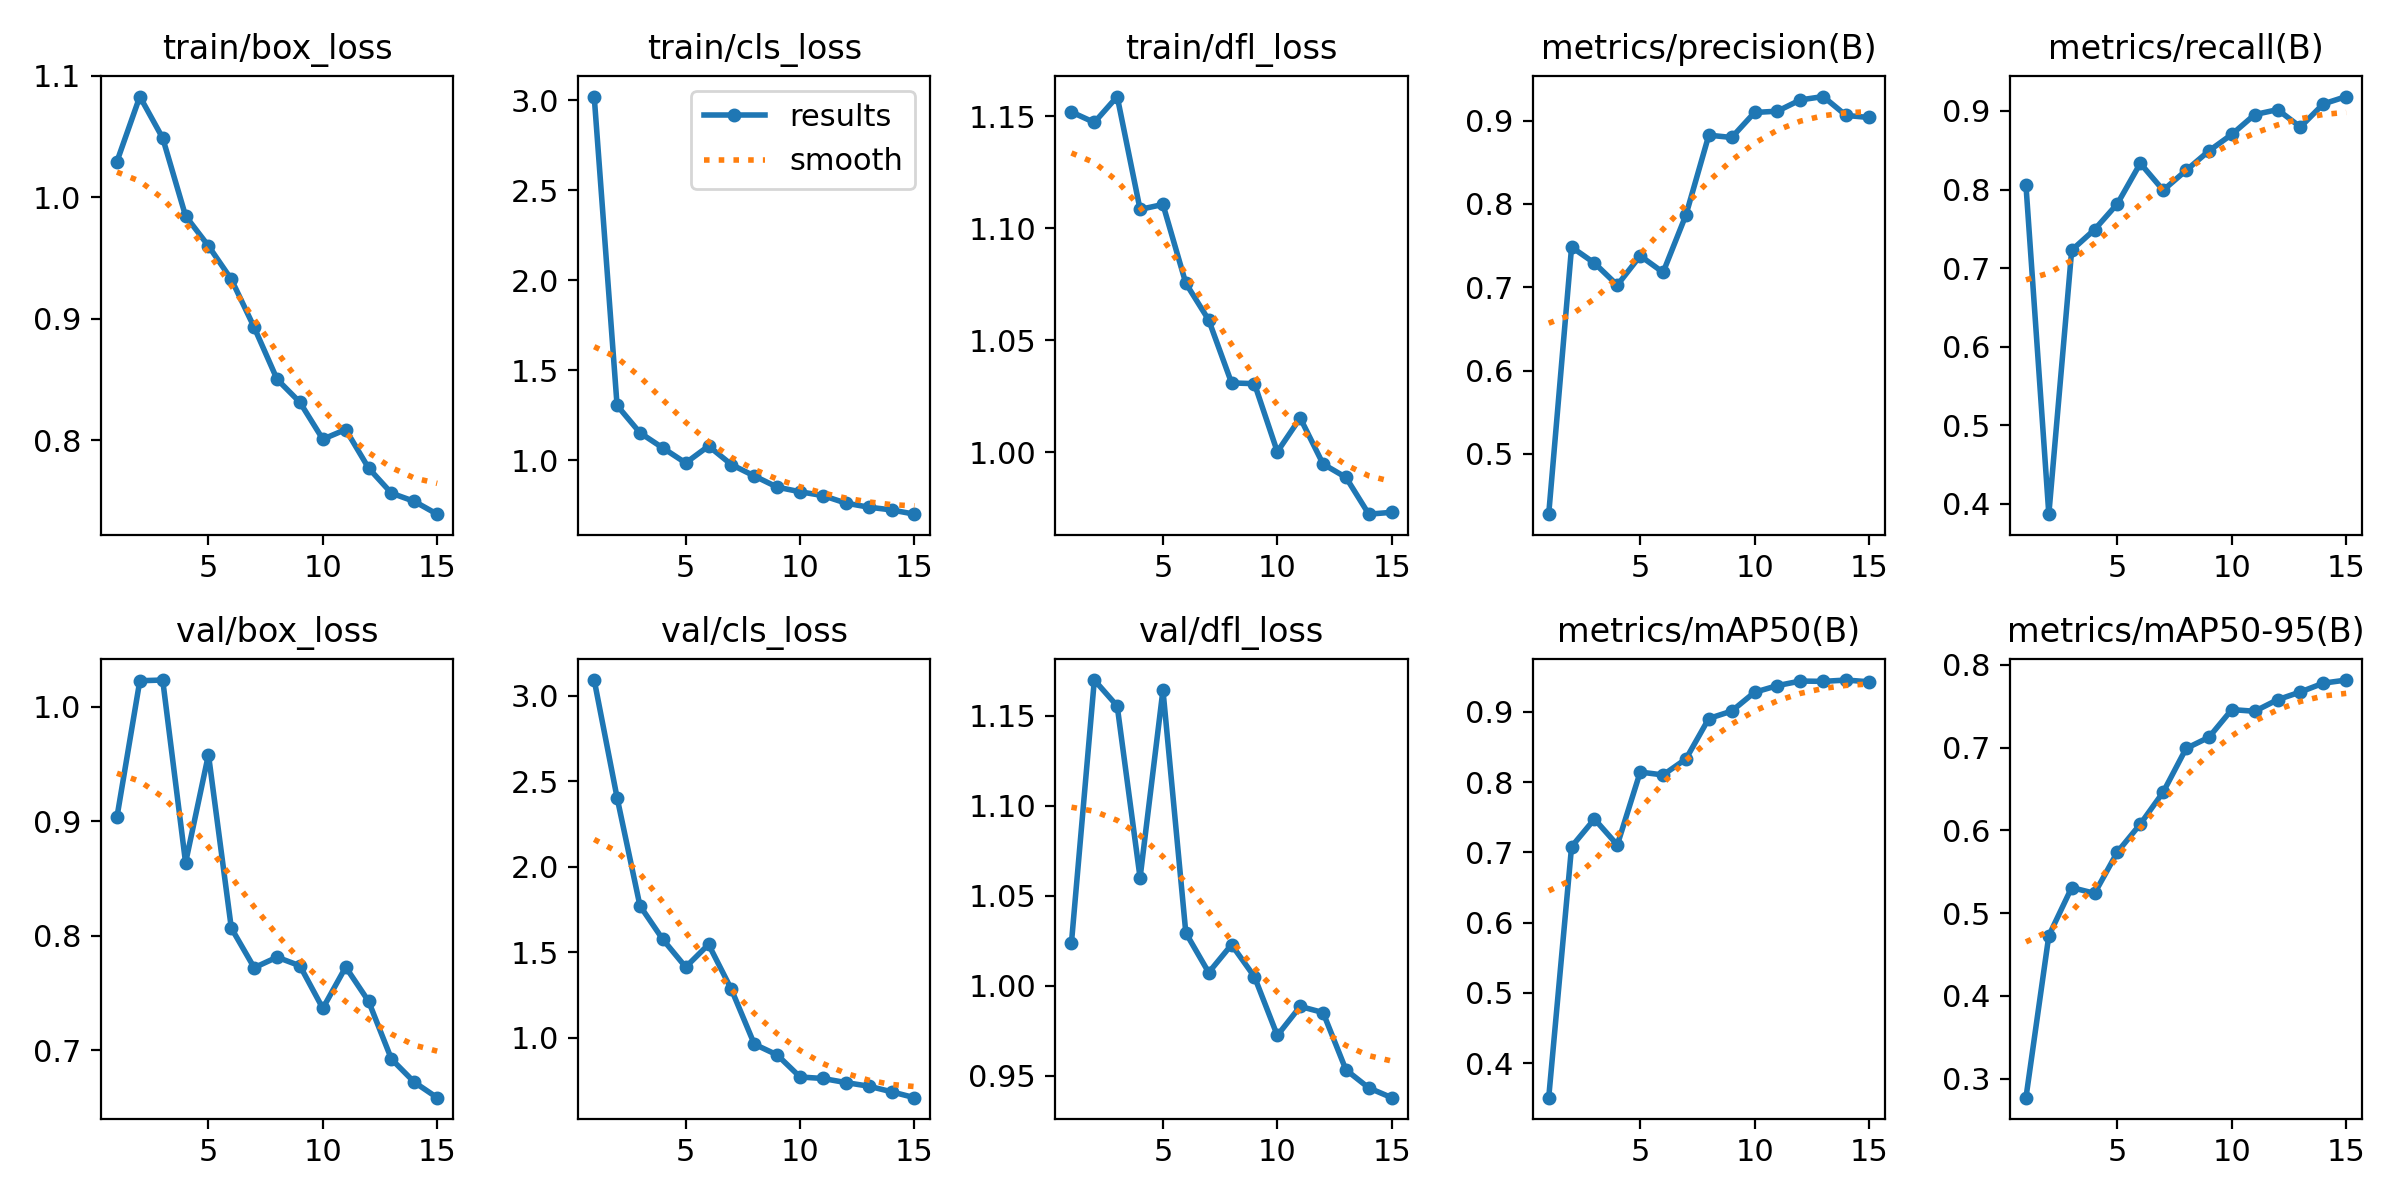

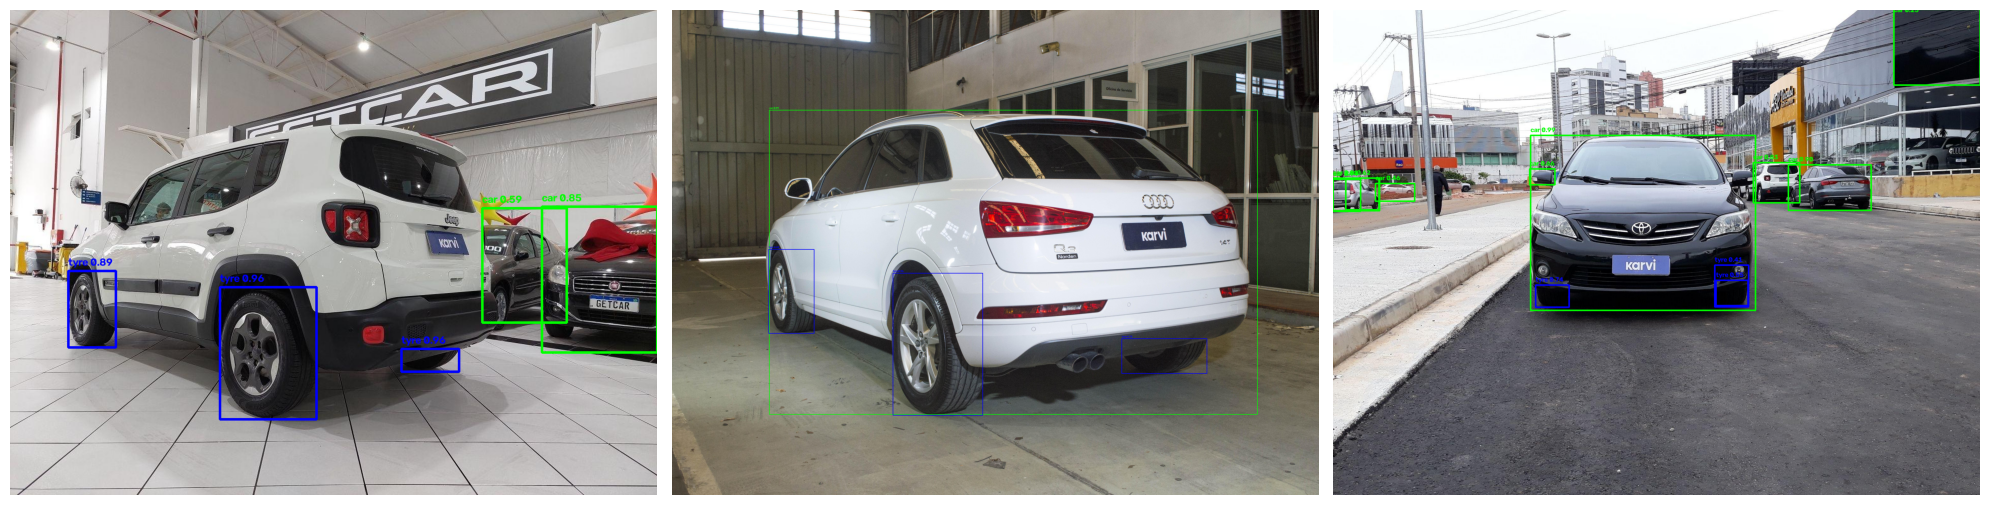

In [11]:
search_paths = [
    '/content/runs/detect/car_tyre_project/*/results.png',
    '/content/runs/detect/car_tyre_project/results.png',
    'runs/detect/car_tyre_project/*/results.png'
]

results_path = None
for path in search_paths:
    found_files = glob.glob(path)
    if found_files:
        results_path = sorted(found_files)[-1]
        break

if results_path:
    display(Image(filename=results_path, width=900))

    best_model_path = results_path.replace('results.png', 'weights/best.pt')
    if os.path.exists(best_model_path):
        model = YOLO(best_model_path)
        val_images = glob.glob('/content/car_tyre_dataset/valid/images/**/*.jpg', recursive=True)

        if len(val_images) >= 3:
            sample_images = random.sample(val_images, 3)
            plt.figure(figsize=(20, 8))

            for i, img_path in enumerate(sample_images):
                results = model.predict(img_path, conf=0.25, verbose=False)
                img = cv2.imread(img_path)

                for r in results:
                    if r.boxes is not None:
                        for box in r.boxes:
                            x1, y1, x2, y2 = map(int, box.xyxy[0])
                            conf = float(box.conf[0])
                            cls_id = int(box.cls[0])
                            label = f"{model.names[cls_id]} {conf:.2f}"

                            color = (0, 255, 0) if cls_id == 0 else (255, 0, 0)
                            cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
                            cv2.putText(img, label, (x1, max(y1 - 10, 10)),
                                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                plt.subplot(1, 3, i + 1)
                plt.imshow(img_rgb)
                plt.axis('off')

            plt.tight_layout()
            plt.show()